In [ ]:
from IPython.display import clear_output

In [ ]:
# Download the required libraries (needed when running outside colab where the environment doesn't come pre-loaded with libraries)
%pip install torch
%pip install matplotlib
%pip install scikit-learn

clear_output()

In [ ]:
import torch
import torch.nn as nn
from torch.optim import SGD, Adam
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Loading & Preprocessing Data

In [ ]:
data = load_breast_cancer()

In [ ]:
print(data.DESCR)  # description of dataset

In [ ]:
print('feature_names:', data.feature_names)
print('-'*20)
print('target_names:', data.target_names)

feature_names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
--------------------
target_names: ['malignant' 'benign']


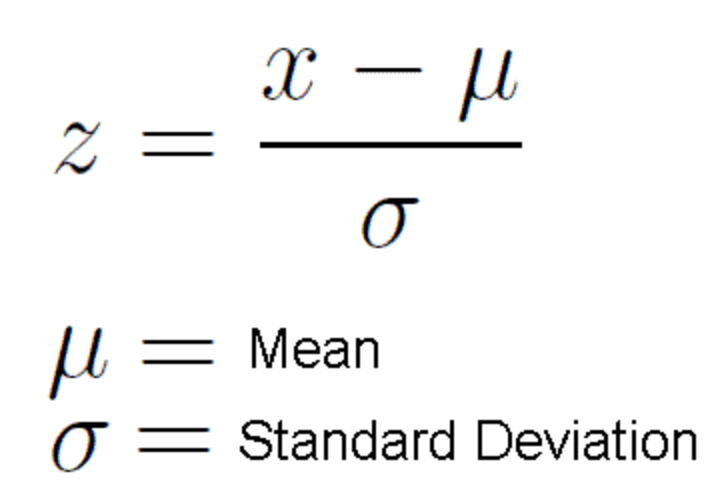

In [ ]:
len(data.feature_names)

30

In [ ]:
# Load the Breast Cancer dataset
X = data.data
y = data.target

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)


## Splitting the data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Convert data to tensor

In [ ]:
# Split the dataset into training and testing sets
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.float32)

In [ ]:
print(f'{X.shape=}')
print(f'{y.shape=}')
print('-'*10)
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print('-'*10)
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')

X.shape=(569, 30)
y.shape=(569,)
----------
X_train.shape=torch.Size([455, 30])
X_test.shape=torch.Size([114, 30])
----------
y_train.shape=torch.Size([455])
y_test.shape=torch.Size([114])


## Model creation


In [ ]:
# Torch module based model for logistic_regression
class LogisticRegression1Layer(nn.Module):
  def __init__(self, input_dim):
    super(LogisticRegression1Layer, self).__init__()
    self.linear1 = nn.Linear(input_dim, 1)

  def forward(self, x):
    z = self.linear1(x)
    a = torch.sigmoid(z)  # a sigmoid over a linear layer output
    return a


In [ ]:
class LogisticRegression2Layer(nn.Module):
  def __init__(self, num_inp, num_hidden):

    super(LogisticRegression2Layer, self).__init__()

    self.layer_1 = nn.Linear(num_inp, num_hidden)
    self.layer_2 = nn.Linear(num_hidden, 1)
    self.hidden_activation = nn.ReLU()  # We can change the hidden activation (activation in between layer 1 and 2) here

  def forward(self, x):

    z1 = self.layer_1(x)
    a1 = self.hidden_activation(z1)

    z2 = self.layer_2(a1)
    a2 = torch.sigmoid(z2)

    return a2

In [ ]:
input_dim = X_train.shape[1]
num_hidden = 20
model = LogisticRegression1Layer(input_dim)
#model = LogisticRegression2Layer(input_dim, num_hidden)

# Define loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross Entropy Loss (binary because 2 classes). Cross entropy function in torch is multi-class
optimizer = SGD(model.parameters(), lr=0.01)

num_epochs = 1000

## Training the model

In [ ]:
train_losses = []

for epoch in range(num_epochs):
  # Forward pass
  outputs = model(X_train)
  loss = criterion(outputs, y_train.unsqueeze(dim=-1))

  # Backward pass and optimization
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  train_losses.append(loss.item())

  if (epoch + 1) % 100 == 0:
    print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.2544
Epoch [200/1000], Loss: 0.1862
Epoch [300/1000], Loss: 0.1560
Epoch [400/1000], Loss: 0.1385
Epoch [500/1000], Loss: 0.1267
Epoch [600/1000], Loss: 0.1182
Epoch [700/1000], Loss: 0.1117
Epoch [800/1000], Loss: 0.1065
Epoch [900/1000], Loss: 0.1023
Epoch [1000/1000], Loss: 0.0988


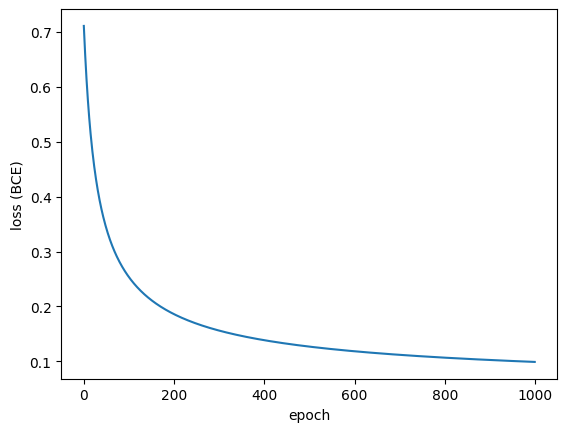

In [ ]:
plt.plot(train_losses)
plt.xlabel('epoch')
plt.ylabel('loss (BCE)')
plt.show()

## Evaluating the model

In [ ]:
model.eval()
with torch.no_grad():

  y_pred = model(X_test)
  y_pred = (y_pred > 0.5).float()  # Convert probabilities to binary predictions (0 or 1)

  correct = (y_pred == y_test.view(-1, 1)).sum().item()
  accuracy = correct / len(y_test)

  print(f'Accuracy on test set: {100 * accuracy:.2f}%')

Accuracy on test set: 96.49%
